## 03_bar_charts

In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("../data/checking-logs.sqlite")
cur = conn.cursor()

### анализируйте только пользователей, а не администраторо

In [2]:
checker = pd.read_sql(
    """
        SELECT timestamp
        FROM checker
        WHERE uid LIKE 'user_%' 
    """,
    conn,
    parse_dates="timestamp",
)
checker["date"] = checker.timestamp.dt.date
checker["hour"] = checker.timestamp.dt.hour
checker["type"] = checker.timestamp.dt.dayofweek.apply(
    lambda x: "working_day" if x < 5 else "weekend"
)
checker

,timestamp,date,hour,type
0,2020-04-17 05:19:02.744528,2020-04-17,5,working_day
1,2020-04-17 05:22:35.249331,2020-04-17,5,working_day
2,2020-04-17 05:22:45.549397,2020-04-17,5,working_day
3,2020-04-17 05:34:14.691200,2020-04-17,5,working_day
4,2020-04-17 05:34:24.422370,2020-04-17,5,working_day
...,...,...,...,...
3202,2020-05-21 20:19:06.872761,2020-05-21,20,working_day
3203,2020-05-21 20:22:41.785725,2020-05-21,20,working_day
3204,2020-05-21 20:22:41.877806,2020-05-21,20,working_day
3205,2020-05-21 20:37:00.129678,2020-05-21,20,working_day


### для каждого часа рассчитайте среднее количество коммитов в рабочие дни и в выходные (если за час не было коммитов, не используйте его для расчёта среднего значения) и используйте эти значения для своего графика, например: понедельник, 17:00–18:00: 5 коммитов, вторник, 17:00–18:00: 6 коммитов, среда, 17:00–18:00: 7 коммитов

In [3]:
avg_commits = checker.groupby(["type", "date", "hour"]).count()
avg_commits = avg_commits.groupby(["type", "hour"]).mean()["timestamp"].reset_index()
avg_commits

,type,hour,timestamp
0,weekend,0,2.000000
1,weekend,1,6.000000
2,weekend,3,1.000000
3,weekend,5,2.000000
4,weekend,7,4.000000
5,weekend,8,7.000000
6,weekend,9,3.666667
7,weekend,10,7.000000
8,weekend,11,23.600000
9,weekend,12,9.500000


In [4]:
graf = pd.pivot(avg_commits, values="timestamp", index="hour", columns="type")
graf

type,weekend,working_day
hour,,
0,2.000000,3.000000
1,6.000000,NaN
3,1.000000,2.000000
5,2.000000,7.500000
6,NaN,1.500000
7,4.000000,5.166667
8,7.000000,3.700000
9,3.666667,6.000000
10,7.000000,13.200000


array([<Axes: title={'center': 'weekend'}, xlabel='hour'>,
       <Axes: title={'center': 'working_day'}, xlabel='hour'>],
      dtype=object)

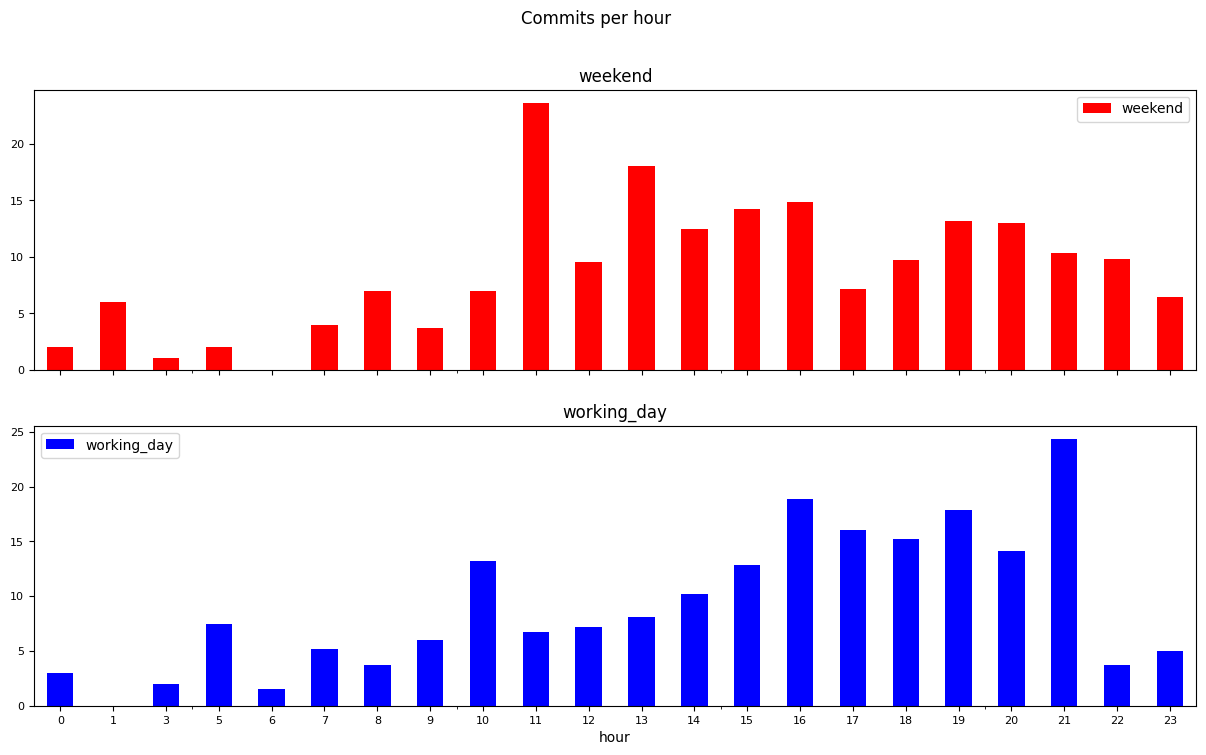

In [5]:
graf.plot.bar(
    figsize=(15, 8),
    title="Commits per hour",
    rot=0,
    fontsize=8,
    color=("r", "b"),
    subplots=True,
)

### Отличается ли динамика в рабочие дни и выходные? Для ответа укажите час, когда количество коммитов наибольшее в рабочие дни, и час, когда оно наибольшее в выходные. Ответ - 21 в рабочии дни, 11 в выходные.

In [6]:
graf[graf["weekend"] == graf["weekend"].max()]

type,weekend,working_day
hour,,
11,23.6,6.769231


In [7]:
graf[graf["working_day"] == graf["working_day"].max()]

type,weekend,working_day
hour,,
21,10.285714,24.333333


In [8]:
conn.close()